In [297]:
! pip install pandas numpy matplotlib scikit-learn seaborn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [298]:
import pandas as pd
import numpy as np
import seaborn as sns
import  sklearn as sk
import matplotlib.pyplot as plt

In [299]:
df = pd.read_csv("./dataset/SOF PUF 2023.CSV", encoding = "ISO-8859-1")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,RREG,RHHNUM,RQ1_LNO,RQ2_REL,RQ3_SEX,RQ4_AGE,RQ5_TMSLEFT,RQ6M_DTLEFT,RQ6Y_DTLEFT,RQ7_MSTAT,...,RQ264P_GIFT,RQ265P_OTHERS,RQ27_RET6MOS,RQ28_CASHHOME,RQ29_INKIND,RQ30_KINDAMT,RSWGT,RP6M_IND,RSVYYR,RPRRCD
0,1,1,81,8,1,65,1,3,2023,2,...,000,000,2,,1,00055000,463.1271,,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,,,2,,2,,463.1271,,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,,,2,,2,,463.1271,,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,000,000,1,0020000,1,00030000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,000,000,2,,2,,456.8271,1,2023,2800


# Cleaning the dataset

In [300]:
df.shape

(4304, 44)

In [301]:
df.isnull().sum()

RREG                     0
RHHNUM                   0
RQ1_LNO                  0
RQ2_REL                  0
RQ3_SEX                  0
RQ4_AGE                  0
RQ5_TMSLEFT              0
RQ6M_DTLEFT              0
RQ6Y_DTLEFT              0
RQ7_MSTAT                0
RQ8_HGRADE               0
RQ9_2DGT                 0
RQ10_REASON              0
RQ11_BASE                0
RQ12_CTRY                0
RQ13_RETURN              0
RQ14_INDWORK             0
RQ15_2DGT                0
RQ16_2DGT                0
RQ17_AVEMINC             0
RQ18_NOMONTH             0
RQ19_RET                 0
RQ20M_DTRET              0
RQ20Y_DTRET              0
RQ21_REASON              0
RQ22M_DTEXP              0
RQ22Y_DTEXP              0
RQ23_CASHREM             0
RQ24_CASHAMT             0
RQ25_MODE                0
RQ26_REMITTANCE_SPENT    0
RQ261P_CONSUM            0
RQ262P_INVEST            0
RQ263P_SAVINGS           0
RQ264P_GIFT              0
RQ265P_OTHERS            0
RQ27_RET6MOS             0
R

In [302]:
df.duplicated().sum()

np.int64(0)

In [303]:
df.dtypes

RREG                       int64
RHHNUM                     int64
RQ1_LNO                    int64
RQ2_REL                    int64
RQ3_SEX                    int64
RQ4_AGE                    int64
RQ5_TMSLEFT                int64
RQ6M_DTLEFT                int64
RQ6Y_DTLEFT                int64
RQ7_MSTAT                    str
RQ8_HGRADE                   str
RQ9_2DGT                     str
RQ10_REASON                int64
RQ11_BASE                    str
RQ12_CTRY                  int64
RQ13_RETURN                int64
RQ14_INDWORK               int64
RQ15_2DGT                    str
RQ16_2DGT                    str
RQ17_AVEMINC                 str
RQ18_NOMONTH                 str
RQ19_RET                   int64
RQ20M_DTRET                  str
RQ20Y_DTRET                  str
RQ21_REASON                  str
RQ22M_DTEXP                  str
RQ22Y_DTEXP                  str
RQ23_CASHREM               int64
RQ24_CASHAMT                 str
RQ25_MODE                    str
RQ26_REMIT

In [304]:
str_col_names=df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in str_col_names:
    if col == "RQ26_REMITTANCE_SPENT":
        df[col] = df[col].str.strip().fillna("")
        continue
    df[col] = pd.to_numeric(df[col].str.strip(), errors="coerce").astype("Int64")
df

,RREG,RHHNUM,RQ1_LNO,RQ2_REL,RQ3_SEX,RQ4_AGE,RQ5_TMSLEFT,RQ6M_DTLEFT,RQ6Y_DTLEFT,RQ7_MSTAT,...,RQ264P_GIFT,RQ265P_OTHERS,RQ27_RET6MOS,RQ28_CASHHOME,RQ29_INKIND,RQ30_KINDAMT,RSWGT,RP6M_IND,RSVYYR,RPRRCD
0,1,1,81,8,1,65,1,3,2023,2,...,0,0,2,<NA>,1,55000,463.1271,<NA>,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,0,0,1,20000,1,30000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,0,0,2,<NA>,2,<NA>,456.8271,1,2023,2800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,19,3697,2,2,2,29,1,6,2019,2,...,0,0,2,<NA>,2,<NA>,294.8777,1,2023,99900
4300,19,3698,2,2,2,38,2,10,2022,2,...,0,0,2,<NA>,2,<NA>,382.1495,1,2023,99900
4301,19,3699,2,2,2,48,2,5,2021,2,...,0,0,2,<NA>,2,<NA>,345.1758,1,2023,99900
4302,19,3700,2,2,2,23,1,3,2019,2,...,0,0,2,<NA>,1,17000,294.2764,1,2023,99900


In [305]:
column_names = [
    "region",
    "household_unique_sequential_number",
    "line_number",
    "relationship",
    "sex",
    "age",
    "times_left_year_ago",
    "left_month",
    "left_year",
    "marital_status",
    "highest_grade_completed",
    "usual_occupation",
    "reason_for_leaving",
    "base",
    "destination_country",
    "expected_return",
    "ever_worked",
    "overseas_employment_type",
    "overseas_industry",
    "average_monthly_income",
    "number_of_months_worked",
    "has_returned_home",
    "returned_home_month",
    "returned_home_year",
    "reason_for_returning",
    "expected_return_home_month",
    "expected_return_home_year",
    "remittance_received",
    "total_remittance",
    "mode_of_remittance",
    "remittance_spent",
    "consumptions_percent",
    "investments_percent",
    "savings_percent",
    "donation_percent",
    "other_spending_percent",
    "returned_apr_sep_2023",
    "cash_brought_home",
    "receive_goods",
    "total_imputed_value",
    "weight",
    "past_six_month_indicator",
    "survey_year",
    "province_code"
]

def rename_columns(df):
    """Renaming data frame columns from name to label"""
    df.columns = column_names

rename_columns(df)
df.head()

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,donation_percent,other_spending_percent,returned_apr_sep_2023,cash_brought_home,receive_goods,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code
0,1,1,81,8,1,65,1,3,2023,2,...,0,0,2,<NA>,1,55000,463.1271,<NA>,2023,2800
1,1,1,82,8,2,72,1,3,2023,2,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
2,1,1,83,8,2,30,1,3,2023,1,...,<NA>,<NA>,2,<NA>,2,<NA>,463.1271,<NA>,2023,2800
3,1,2,4,3,2,42,2,9,2023,3,...,0,0,1,20000,1,30000,456.8271,1,2023,2800
4,1,3,2,2,2,43,1,4,2023,2,...,0,0,2,<NA>,2,<NA>,456.8271,1,2023,2800


In [306]:
# maps for categorical data
region = {
    1: "Ilocos",
    2: "Cagayan Valley",
    3: "Central Luzon",
    4: "CALABARZON",
    5: "Bicol",
    6: "Western Visayas",
    7: "Central Visayas",
    8: "Eastern Visayas",
    9: "Zamboanga Peninsula",
    10: "Northern Mindanao",
    11: "Davao Region",
    12: "SOCCSKSARGEN",
    13: "NCR",
    14: "CAR",
    16: "Caraga",
    17: "MIMAROPA",
    19: "ARMM",
}

relationship = {
    1: "Head",
    2: "Spouse",
    3: "Child",
    4: "Sibling",
    5: "Spouse's child",
    6: "Grandchild",
    7: "Parent",
    8: "Other relative"
}

sex = {
    1: "Male",
    2: "Female"
}

months = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

marital_status = {
    1: "Single",
    2: "Married",
    3: "Widowed",
    4: "Separated",
    5: "Live-in",
    6: "Unknown"
}

highest_grade_completed = {
    0: "None",
    1: "Elementary undergraduate",
    2: "Elementary graduate",
    3: "Junior high undergraduate",
    4: "Junior high graduate",
    5: "Senior high undergraduate",
    6: "Senior high graduate",
    7: "Post secondary undergraduate",
    8: "Post secondary graduate",
    9: "College undergraduate",
    10: "College graduate",
    11: "Post graduate"
}

occupation = {
    1: "Armed forces occupations",
    2: "Armed forces occupations",
    3: "Armed forces occupations",
    9: "Non-gainful occupations",
    11: "Manager",
    12: "Manager",
    13: "Manager",
    14: "Manager",
    21: "Professionals",
    22: "Professionals",
    23: "Professionals",
    24: "Professionals",
    25: "Professionals",
    26: "Professionals",
    31: "Technicians and associate professionals",
    32: "Technicians and associate professionals",
    33: "Technicians and associate professionals",
    34: "Technicians and associate professionals",
    35: "Technicians and associate professionals",
    41: "Clerical support workers",
    42: "Clerical support workers",
    43: "Clerical support workers",
    44: "Clerical support workers",
    51: "Service and sales workers",
    52: "Service and sales workers",
    53: "Service and sales workers",
    54: "Service and sales workers",
    61: "Skilled agricultural, forestry and fishery workers",
    62: "Skilled agricultural, forestry and fishery workers",
    63: "Skilled agricultural, forestry and fishery workers",
    71: "Craft and related trades worker",
    72: "Craft and related trades worker",
    73: "Craft and related trades worker",
    74: "Craft and related trades worker",
    75: "Craft and related trades worker",
    81: "Plant and machine operators and assemblers",
    82: "Plant and machine operators and assemblers",
    83: "Plant and machine operators and assemblers",
    91: "Elementary Occupations",
    92: "Elementary Occupations",
    93: "Elementary Occupations",
    94: "Elementary Occupations",
    95: "Elementary Occupations",
    96: "Elementary Occupations",
    100: "Unemployed"
}

reason_for_leaving = {
    1: "OFW with contract",
    2: "OFW without contract",
    3: "Work with Philippine embassy/consulate abroad",
    4: "Tourist",
    5: "Student",
    6: "Immigrant",
    7: "Official mission",
    8: "Other reason"
}

base = {
    1: "Land",
    2: "Sea",
    3: "Others"
}

destination_country = {code: "Other countries in East Asia" for code in range(211,215)}
destination_country.update({code: "Other countries in SE & SC Asia" for code in range(221, 224)})
destination_country.update({code: "Other countries in Western Asia" for code in range(231, 236)})
specific_countries = {
    100: "Africa", 300: "Australia", 400: "Europe", 500: "North and South America", 600: "Other Countries",
    211: "Hongkong", 212: "Japan", 213: "Taiwan",
    221: "Malaysia", 222: "Singapore",
    231: "Kuwait", 232: "Qatar", 233: "Saudi Arabia", 234: "United Arab Emirates"
}

yes_no = {
    1: True,
    2: False,
}

overseas_industry = {code: "Agriculture and Forestry" for code in range(1,2)}
overseas_industry.update({code: "Mining and Quarrying" for code in range(5,9)})
overseas_industry.update({code: "Manufacturing" for code in range(10,33)})
overseas_industry.update({code: "Water Supply; Sewerage, Waste Management and Remediation Activities" for code in range(36,39)})
overseas_industry.update({code: "Construction" for code in range(41,43)})
overseas_industry.update({code: "Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles" for code in range(45,47)})
overseas_industry.update({code: "Transportation and Storage" for code in range(49,53)})
overseas_industry.update({code: "Accommodation and Food Service Activities" for code in range(55,56)})
overseas_industry.update({code: "Information and Communication" for code in range(58,63)})
overseas_industry.update({code: "Financial and Insurance Activities" for code in range(64,66)})
overseas_industry.update({code: "Professional, Scientific, and Technical Activities" for code in range(69,75)})
overseas_industry.update({code: "Administrative and Support Service Activities" for code in range(77,82)})
overseas_industry.update({code: "Human Health and Social Work Activities" for code in range(86,88)})
overseas_industry.update({code: "Arts, Entertainment and Recreation" for code in range(90,93)})
overseas_industry.update({code: "Other Service Activities" for code in range(94,96)})
overseas_industry.update({code: "Activities of Households as Employers" for code in range(97,98)})
specific_industries = {
    3: "Fishing and Aquaculture",
    35: "Electricity, Gas, Steam and Air Conditioning Supply",
    68: "Real Estate Activities", 84: "Public Administration and Defense; Compulsory Social Security", 85: "Education",
    99: "Activities of Extraterritorial Organizations and Bodies"
}

reason_for_returning = {
    1: "Visit friends and relatives",
    2: "End of contract",
    3: "Repatriated due to COVID-19",
    4: "Others"
}

remittance_received = {
    1: "With Remittance",
    2: "Without Remittance",
    3: "Not Reported"
}

mode_of_remittance = {
    1:  "Bank",
    2: "Agency/Local Office",
    3: "Friends/Co-workers",
    4: "Door-to-Door",
    5: "Money Transfer Services",
    6: "Other Mode"
}

remittance_spent = {
    "A": "spent_consumptions",
    "B": "spent_investments",
    "C": "spent_savings",
    "D": "spent_donations",
    "E": "spent_other"
}

province_code = {
    80500: "Mandaluyong", 80600: "Manila", 81400: "San Juan",
    81300: "Quezon City", 80700: "Marikina",
    80300: "Makati City", 81200: "Pasig City", 81700: "Pateros", 81500: "Taguig City",
    80100: "Caloocan City", 80400: "Malabon City", 80900: "Navotas City", 81600: "Valenzuela City",
    80200: "Las Pinas", 80800: "Muntinlupa", 81000: "Paranaque", 81100: "Pasay City",
    100: "Abra", 1100: "Benguet", 30300: "Baguio City", 2700: "Ifugao", 3200: "Kalinga", 4400: "Mountain Province", 8100: "Apayao",
    2800: "Ilocos Norte", 2900: "Ilocos Sur", 3300: "La Union", 5500: "Pangasinan",
    900: "Batanes", 1500: "Cagayan", 3100: "Isabela", 5000: "Nueva Vizcaya", 5700: "Quirino",
    7700: "Aurora", 800: "Bataan", 1400: "Bulacan", 4900: "Nueva Ecija",
    5400: "Pampanga", 30100: "Angeles City", 6900: "Tarlac", 7100: "Zambales", 31400: "Olongapo City",
    1000: "Batangas", 2100: "Cavite", 3400: "Laguna", 5600: "Quezon", 31200: "Lucena City", 5800: "Rizal",
    4000: "Marinduque", 5100: "Occidental Mindoro", 5200: "Oriental Mindoro", 5300: "Palawan", 31500: "Puerto Princesa City", 5900: "Romblon",
    500: "Albay", 1600: "Camarines Norte", 1700: "Camarines Sur", 2000: "Catanduanes", 4100: "Masbate", 6200: "Sorsogon",
    400: "Aklan", 600: "Antique", 1900: "Capiz", 3000: "Iloilo", 31000: "Iloilo City", 4500: "Negros Occidental", 30200: "Bacolod City", 7900: "Guimaras",
    1200: "Bohol", 2200: "Cebu", 30600: "Cebu City", 31100: "Lapulapu City", 31300: "Mandaue City", 4600: "Negros Oriental", 6100: "Siquijor",
    2600: "Eastern Samar", 3700: "Leyte", 31600: "Tacloban City", 4800: "Northern Samar", 6000: "Samar (Western)", 6400: "Southern Leyte", 7800: "Biliran",
    7200: "Zambales del Norte", 7300: "Zamboanga del Sur", 31700: "Zamboanga City", 8300: "Zamboanga Sibugay", 90100: "Isabela City",
    1300: "Bukidnon", 1800: "Camiguin", 3500: "Lanao del Norte", 30900: "Iligan City", 4200: "Misamis Occidental", 4300: "Misamis Oriental", 30500: "Cagayan de Oro City",
    2300: "Davao del Norte", 2400: "Davao del Sur", 30700: "Davao City", 2500: "Davao Oriental", 8200: "Compostela Valley", 8600: "Davao Occidental",
    4700: "North Cotabato", 6300: "South Cotabato", 30800: "General Santos City", 6500: "Sultan Kudarat", 8000: "Sarangani",
    200: "Agusan del Norte", 30400: "Butuan City", 300: "Agusan del Sur", 6700: "Surigao del Norte", 6800: "Surigao del Sur", 8500: "Dinagat Island",
    700: "Basilan", 3600: "Lanao del Sur", 8700: "Maguindanao del Norte", 8703: "Cotabato City", 8800: "Maguindanao del Sur", 6600: "Sulu", 7000: "Tawi-Tawi", 99900: "BARMM63"
}

In [307]:
categorical_columns = {
    "region": region,
    "relationship": relationship,
    "sex": sex,
    "left_month": months,
    "marital_status": marital_status,
    "highest_grade_completed": highest_grade_completed,
    "usual_occupation": occupation,
    "reason_for_leaving": reason_for_leaving,
    "base": base,
    "destination_country": destination_country,
    "ever_worked": yes_no,
    "overseas_employment_type": occupation,
    "overseas_industry": overseas_industry,
    "has_returned_home": yes_no,
    "returned_home_month": months,
    "reason_for_returning": reason_for_returning,
    "expected_return_home_month": months,
    "remittance_received": remittance_received,
    "mode_of_remittance": mode_of_remittance,
    "returned_apr_sep_2023": yes_no,
    "receive_goods": yes_no,
    "province_code": province_code
}

for col, mappings in categorical_columns.items():
    df[col] = df[col].map(mappings)

for code, label in remittance_spent.items():
    df[label] = df["remittance_spent"].str.contains(code)

df

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code,spent_consumptions,spent_investments,spent_savings,spent_donations,spent_other
0,Ilocos,1,81,Other relative,Male,65,1,Mar,2023,Married,...,55000,463.1271,<NA>,2023,Ilocos Norte,True,False,False,False,False
1,Ilocos,1,82,Other relative,Female,72,1,Mar,2023,Married,...,<NA>,463.1271,<NA>,2023,Ilocos Norte,False,False,False,False,False
2,Ilocos,1,83,Other relative,Female,30,1,Mar,2023,Single,...,<NA>,463.1271,<NA>,2023,Ilocos Norte,False,False,False,False,False
3,Ilocos,2,4,Child,Female,42,2,Sep,2023,Widowed,...,30000,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
4,Ilocos,3,2,Spouse,Female,43,1,Apr,2023,Married,...,<NA>,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,ARMM,3697,2,Spouse,Female,29,1,Jun,2019,Married,...,<NA>,294.8777,1,2023,BARMM63,True,False,False,False,False
4300,ARMM,3698,2,Spouse,Female,38,2,Oct,2022,Married,...,<NA>,382.1495,1,2023,BARMM63,True,True,False,False,False
4301,ARMM,3699,2,Spouse,Female,48,2,May,2021,Married,...,<NA>,345.1758,1,2023,BARMM63,True,False,False,False,False
4302,ARMM,3700,2,Spouse,Female,23,1,Mar,2019,Married,...,17000,294.2764,1,2023,BARMM63,True,False,False,False,False


In [308]:
df.isnull().sum()

region                                   0
household_unique_sequential_number       0
line_number                              0
relationship                             0
sex                                      0
age                                      0
times_left_year_ago                      0
left_month                               0
left_year                                0
marital_status                           8
highest_grade_completed                152
usual_occupation                         4
reason_for_leaving                       0
base                                   729
destination_country                    993
expected_return                          0
ever_worked                              0
overseas_employment_type               692
overseas_industry                     2815
average_monthly_income                 692
number_of_months_worked                692
has_returned_home                        0
returned_home_month                   2771
returned_ho

In [309]:
missing = df.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

total_imputed_value           90.566914
cash_brought_home             81.552045
overseas_industry             65.404275
returned_home_month           64.381970
returned_home_year            64.381970
reason_for_returning          64.381970
expected_return_home_month    44.400558
expected_return_home_year     35.618030
other_spending_percent        33.805762
investments_percent           33.712825
donation_percent              33.689591
mode_of_remittance            33.480483
savings_percent               33.480483
consumptions_percent          33.480483
total_remittance              33.085502
destination_country           23.071561
base                          16.937732
overseas_employment_type      16.078067
number_of_months_worked       16.078067
average_monthly_income        16.078067
highest_grade_completed        3.531599
past_six_month_indicator       1.324349
marital_status                 0.185874
usual_occupation               0.092937
dtype: float64

In [310]:
df.duplicated().sum()

np.int64(0)

In [311]:
# =============================================================================
# 1. BASELINE DEMOGRAPHICS & DEPARTURE DETAILS (C1 - C9)
# =============================================================================

# Baseline demographic imputations (True omissions)
df['marital_status'] = df['marital_status'].fillna('Unknown')
df['past_six_month_indicator'] = df['past_six_month_indicator'].fillna(0)

# Mode imputation for random missing arrival/departure details
df['left_month'] = df['left_month'].fillna(df['left_month'].mode()[0])
df['left_year'] = df['left_year'].fillna(df['left_year'].mode()[0])

# Contextual imputation for education based on occupation
df['highest_grade_completed'] = df.groupby('usual_occupation')['highest_grade_completed'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "College graduate")
)


# =============================================================================
# 2. EMPLOYMENT FILTER & PROFILE DETAILS (C10 - C19)
# =============================================================================

# Mask for individuals who explicitly did not work abroad (C14)
no_work_mask = df['ever_worked'] == False

# Handle structural skips for non-working individuals
df.loc[no_work_mask, 'average_monthly_income'] = 0
df.loc[no_work_mask, ['overseas_employment_type', 'overseas_industry']] = 'Not Applicable (Unemployed)'
df.loc[no_work_mask, 'base'] = 'Not Applicable (Unemployed)'
df.loc[no_work_mask, 'number_of_months_worked'] = 0

# Clean up true omissions and missing slots for the working population
df['base'] = df['base'].fillna('Unknown / Not Reported')
df['overseas_industry'] = df['overseas_industry'].fillna('Unknown')

# Ensure numeric type before calculating group median
df['number_of_months_worked'] = pd.to_numeric(df['number_of_months_worked'], errors='coerce')

needs_duration_imputation = (df['number_of_months_worked'].isna()) & (df['ever_worked'] == True)
active_worker_median = df[df['ever_worked'] == True]['number_of_months_worked'].median()
df.loc[needs_duration_imputation, 'number_of_months_worked'] = active_worker_median

# Enforce uniform column types for employment details
df['base'] = df['base'].astype('object')
df['number_of_months_worked'] = df['number_of_months_worked'].astype('int64')


# =============================================================================
# 3. DESTINATION COUNTRY ROUTING (C12)
# =============================================================================

# Handle sea-based transit workers logically
df.loc[(df['destination_country'].isna()) & (df['base'] == "Sea"), 'destination_country'] = 'Sea-based / International Waters'

# Handle non-work travelers who bypassed destination profiles
df.loc[(df['destination_country'].isna()) & (df['reason_for_leaving'].isin(["Tourist", "Student"])), 'destination_country'] = 'Undisclosed (Non-OFW)'

# Fill remaining absolute blanks as a generic category
df['destination_country'] = df['destination_country'].fillna('Unknown')


# =============================================================================
# 4. RETURNEE TIMELINES & EXPECTED RETURNS (C20 - C23)
# =============================================================================

# Route active workers who are still stationed abroad
not_returned = df["has_returned_home"] == False
df.loc[not_returned, ['reason_for_returning', 'returned_home_month']] = 'Still Abroad'
df.loc[not_returned, 'returned_home_year'] = 0

# Route returned workers (expected return answers are non-applicable)
already_returned = df["has_returned_home"] == True
df.loc[already_returned, "expected_return_home_month"] = "Already Returned"
df.loc[already_returned, "expected_return_home_year"] = 0

# Route active workers remaining abroad with an undisclosed or indefinite timeline
still_abroad_no_date = (df["has_returned_home"] == False) & (df["expected_return_home_month"].isna())
df.loc[still_abroad_no_date, "expected_return_home_month"] = "Indefinite"
df.loc[still_abroad_no_date, "expected_return_home_year"] = 8888

# Cast years cleanly using nullable Int64 to preserve whole integer formatting alongside 0/8888 flags
df["returned_home_year"] = df["returned_home_year"].astype("Int64")
df["expected_return_home_year"] = df["expected_return_home_year"].astype("Int64")


# =============================================================================
# 5. CASH REMITTANCES & VALUE ALLOCATIONS (C24 - C27)
# =============================================================================

percent_cols = [
    'consumptions_percent',
    'savings_percent',
    'investments_percent',
    'donation_percent',
    'other_spending_percent'
]

# Standardize values to numbers first to allow clean mathematical calculations
df['total_remittance'] = pd.to_numeric(df['total_remittance'], errors='coerce')
for col in percent_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Mask for households that did not collect any cash remittances (Using string map values)
no_remittance = df['remittance_received'] == 'Without Remittance'

# Handle structural skips for non-remittance households
df.loc[no_remittance, 'mode_of_remittance'] = 'No Remittance'
df.loc[no_remittance, 'total_remittance'] = 0.0
df.loc[no_remittance, percent_cols] = 0.0

# Handle rare true omissions for active remittance groups
needs_cash_imputation = (df['total_remittance'].isna()) & (df['remittance_received'] == 'With Remittance')
active_remittance_median = df[df['remittance_received'] == 'With Remittance']['total_remittance'].median()
df.loc[needs_cash_imputation, 'total_remittance'] = active_remittance_median

for col in percent_cols:
    remaining_nas = (df[col].isna()) & (df['remittance_received'] == 'With Remittance')
    active_median = df[df['remittance_received'] == 'With Remittance'][col].median()
    df.loc[remaining_nas, col] = active_median

# Finalize data types for financial blocks
df['total_remittance'] = df['total_remittance'].astype('float64')
df[percent_cols] = df[percent_cols].astype('float64')
df['mode_of_remittance'] = df['mode_of_remittance'].astype('object')


# =============================================================================
# 6. PHYSICAL CASH ARRIVALS & IN-KIND GOODS (C28 - C31)
# =============================================================================

# Pre-convert to numeric layout to protect median computations
df['cash_brought_home'] = pd.to_numeric(df['cash_brought_home'], errors='coerce')
df['total_imputed_value'] = pd.to_numeric(df['total_imputed_value'], errors='coerce')

# --- Section A: Cash Brought Home ---
did_not_return_window = df['returned_apr_sep_2023'] == False
df.loc[did_not_return_window, 'cash_brought_home'] = 0.0

needs_cash_home_imputation = (df['cash_brought_home'].isna()) & (df['returned_apr_sep_2023'] == True)
median_cash = df[df['returned_apr_sep_2023'] == True]['cash_brought_home'].median()
df.loc[needs_cash_home_imputation, 'cash_brought_home'] = median_cash

# --- Section B: Total Imputed Value of Goods ---
no_goods = df["receive_goods"] == False
df.loc[no_goods, 'total_imputed_value'] = 0.0

needs_goods_imputation = (df['total_imputed_value'].isna()) & (df['receive_goods'] == True)
median_value = df[df['receive_goods'] == True]['total_imputed_value'].median()
df.loc[needs_goods_imputation, 'total_imputed_value'] = median_value

# Final data type clean up for financial aggregates
df['cash_brought_home'] = df['cash_brought_home'].astype('float64')
df['total_imputed_value'] = df['total_imputed_value'].astype('float64')

In [312]:
missing = df.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

highest_grade_completed    0.092937
usual_occupation           0.092937
dtype: float64

In [313]:
df.head()

,region,household_unique_sequential_number,line_number,relationship,sex,age,times_left_year_ago,left_month,left_year,marital_status,...,total_imputed_value,weight,past_six_month_indicator,survey_year,province_code,spent_consumptions,spent_investments,spent_savings,spent_donations,spent_other
0,Ilocos,1,81,Other relative,Male,65,1,Mar,2023,Married,...,55000.0,463.1271,0,2023,Ilocos Norte,True,False,False,False,False
1,Ilocos,1,82,Other relative,Female,72,1,Mar,2023,Married,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
2,Ilocos,1,83,Other relative,Female,30,1,Mar,2023,Single,...,0.0,463.1271,0,2023,Ilocos Norte,False,False,False,False,False
3,Ilocos,2,4,Child,Female,42,2,Sep,2023,Widowed,...,30000.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False
4,Ilocos,3,2,Spouse,Female,43,1,Apr,2023,Married,...,0.0,456.8271,1,2023,Ilocos Norte,True,False,False,False,False


# EDA

In [314]:
print(df.shape)
df.info()

(4304, 49)
<class 'pandas.DataFrame'>
RangeIndex: 4304 entries, 0 to 4303
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   region                              4304 non-null   str    
 1   household_unique_sequential_number  4304 non-null   int64  
 2   line_number                         4304 non-null   int64  
 3   relationship                        4304 non-null   str    
 4   sex                                 4304 non-null   str    
 5   age                                 4304 non-null   int64  
 6   times_left_year_ago                 4304 non-null   int64  
 7   left_month                          4304 non-null   str    
 8   left_year                           4304 non-null   int64  
 9   marital_status                      4304 non-null   str    
 10  highest_grade_completed             4300 non-null   str    
 11  usual_occupation                    4300 no

In [315]:
df["destination_country"].value_counts()

destination_country
Other countries in Western Asia     1881
Other countries in East Asia         931
Other countries in SE & SC Asia      499
Unknown                              434
Sea-based / International Waters     362
Undisclosed (Non-OFW)                197
Name: count, dtype: int64

In [316]:
df["overseas_industry"].value_counts()

overseas_industry
Unknown                                                                 2123
Not Applicable (Unemployed)                                              692
Transportation and Storage                                               528
Manufacturing                                                            322
Human Health and Social Work Activities                                  204
Construction                                                             154
Accommodation and Food Service Activities                                 63
Administrative and Support Service Activities                             51
Agriculture and Forestry                                                  39
Professional, Scientific, and Technical Activities                        35
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles      35
Information and Communication                                             26
Financial and Insurance Activities                        

## Univariate Analysis

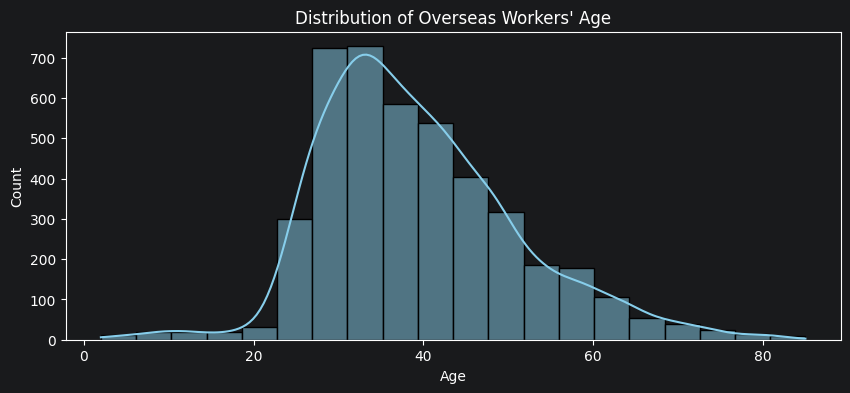

In [317]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Overseas Workers\' Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

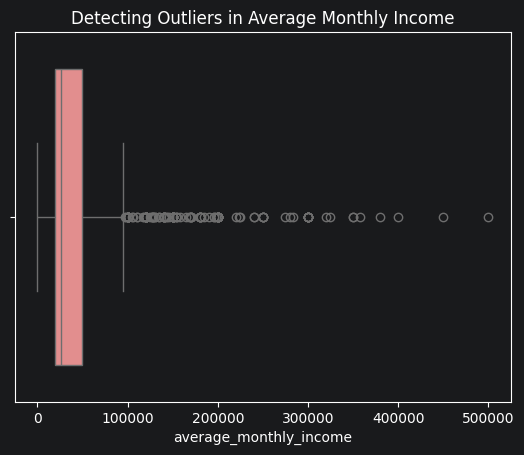

In [318]:
sns.boxplot(data=df, x='average_monthly_income', color='lightcoral')
plt.title('Detecting Outliers in Average Monthly Income')
plt.show()

C:\Users\Joseph Rey\AppData\Local\Temp\ipykernel_26800\2695386356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='region', order=df['region'].value_counts().index, palette='viridis')


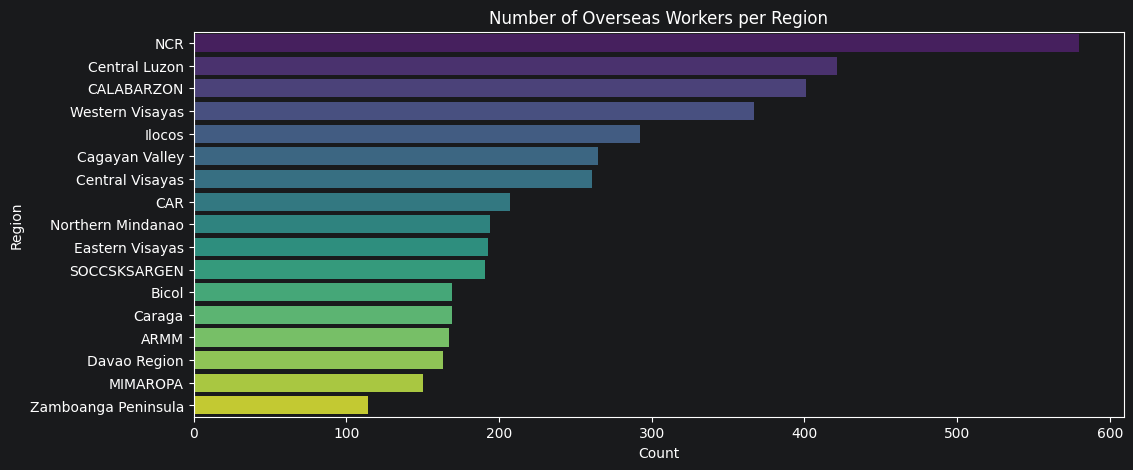

In [322]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='region', order=df['region'].value_counts().index, palette='viridis')
plt.title('Number of Overseas Workers per Region')
plt.xlabel('Count')
plt.ylabel('Region')
plt.show()

# Bivariate & Multivariate Analysis

sex                                                    Female        Male
overseas_industry                                                        
Accommodation and Food Service Activities           50.793651   49.206349
Administrative and Support Service Activities       56.862745   43.137255
Agriculture and Forestry                            38.461538   61.538462
Arts, Entertainment and Recreation                  57.142857   42.857143
Construction                                         5.844156   94.155844
Financial and Insurance Activities                  55.555556   44.444444
Human Health and Social Work Activities             75.000000   25.000000
Information and Communication                       23.076923   76.923077
Manufacturing                                       26.086957   73.913043
Mining and Quarrying                                 0.000000  100.000000
Not Applicable (Unemployed)                         61.416185   38.583815
Other Service Activities              

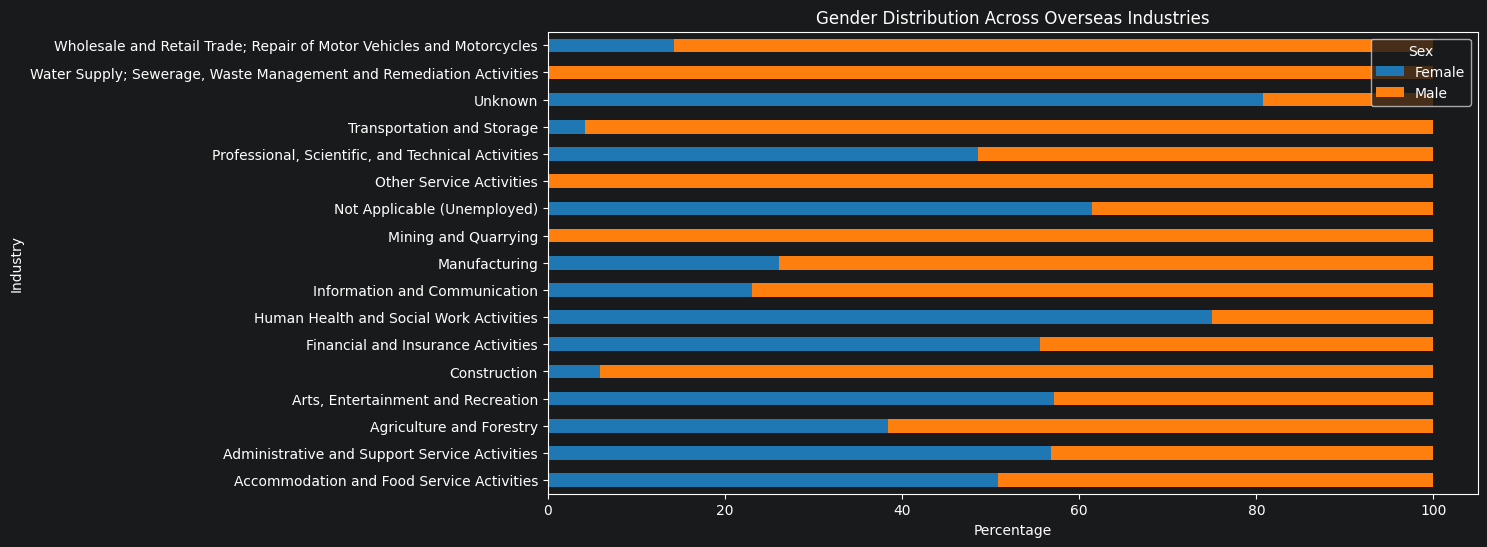

In [323]:
# Create a percentage cross-tabulation table
cross_tab = pd.crosstab(df['overseas_industry'], df['sex'], normalize='index') * 100
print(cross_tab)

# Stacked Bar Chart visualization
cross_tab.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Gender Distribution Across Overseas Industries')
plt.xlabel('Percentage')
plt.ylabel('Industry')
plt.legend(title='Sex')
plt.show()

C:\Users\Joseph Rey\AppData\Local\Temp\ipykernel_26800\4004741491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_remittance.values, y=country_remittance.index, palette='coolwarm')


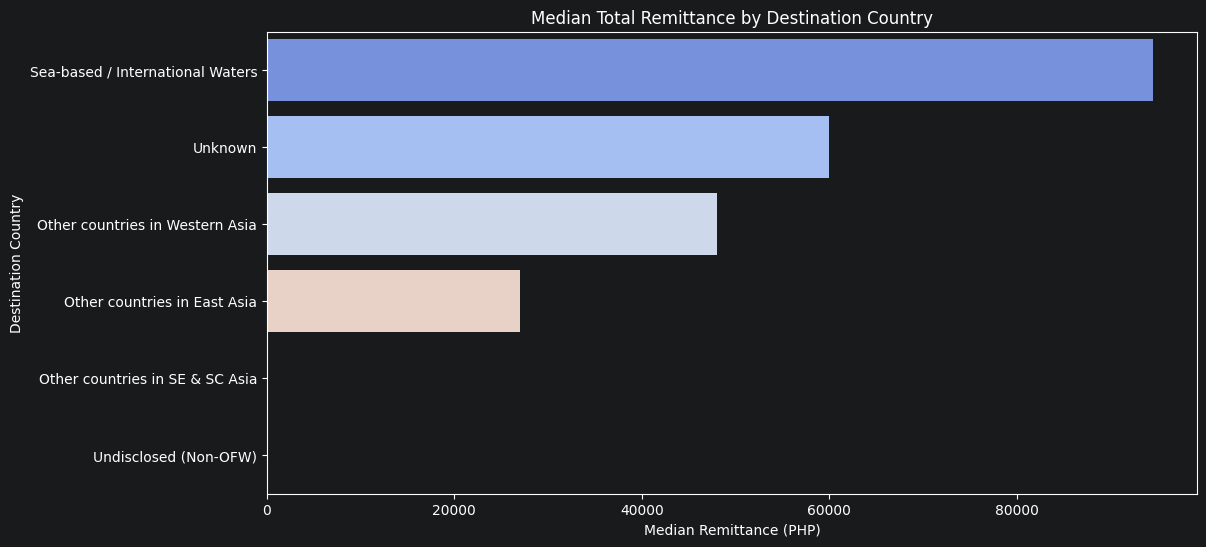

In [325]:
country_remittance = df.groupby('destination_country')['total_remittance'].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_remittance.values, y=country_remittance.index, palette='coolwarm')
plt.title('Median Total Remittance by Destination Country')
plt.xlabel('Median Remittance (PHP)')
plt.ylabel('Destination Country')
plt.show()

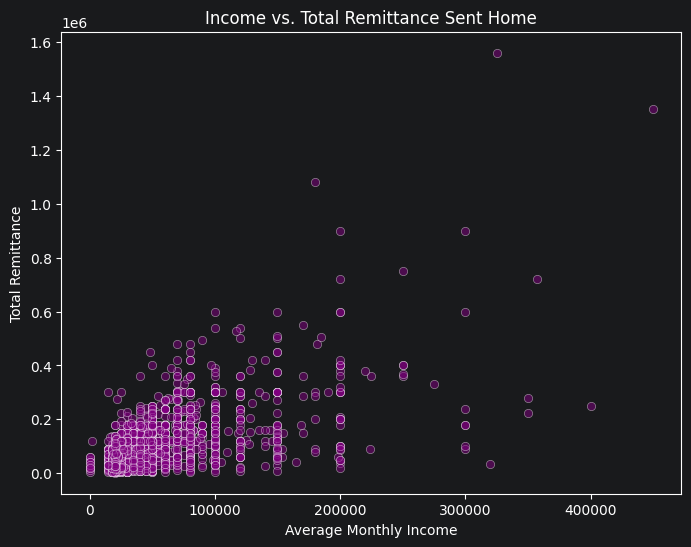

In [326]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df[df['total_remittance'] > 0], x='average_monthly_income', y='total_remittance', alpha=0.5, color='purple')
plt.title('Income vs. Total Remittance Sent Home')
plt.xlabel('Average Monthly Income')
plt.ylabel('Total Remittance')
plt.show()

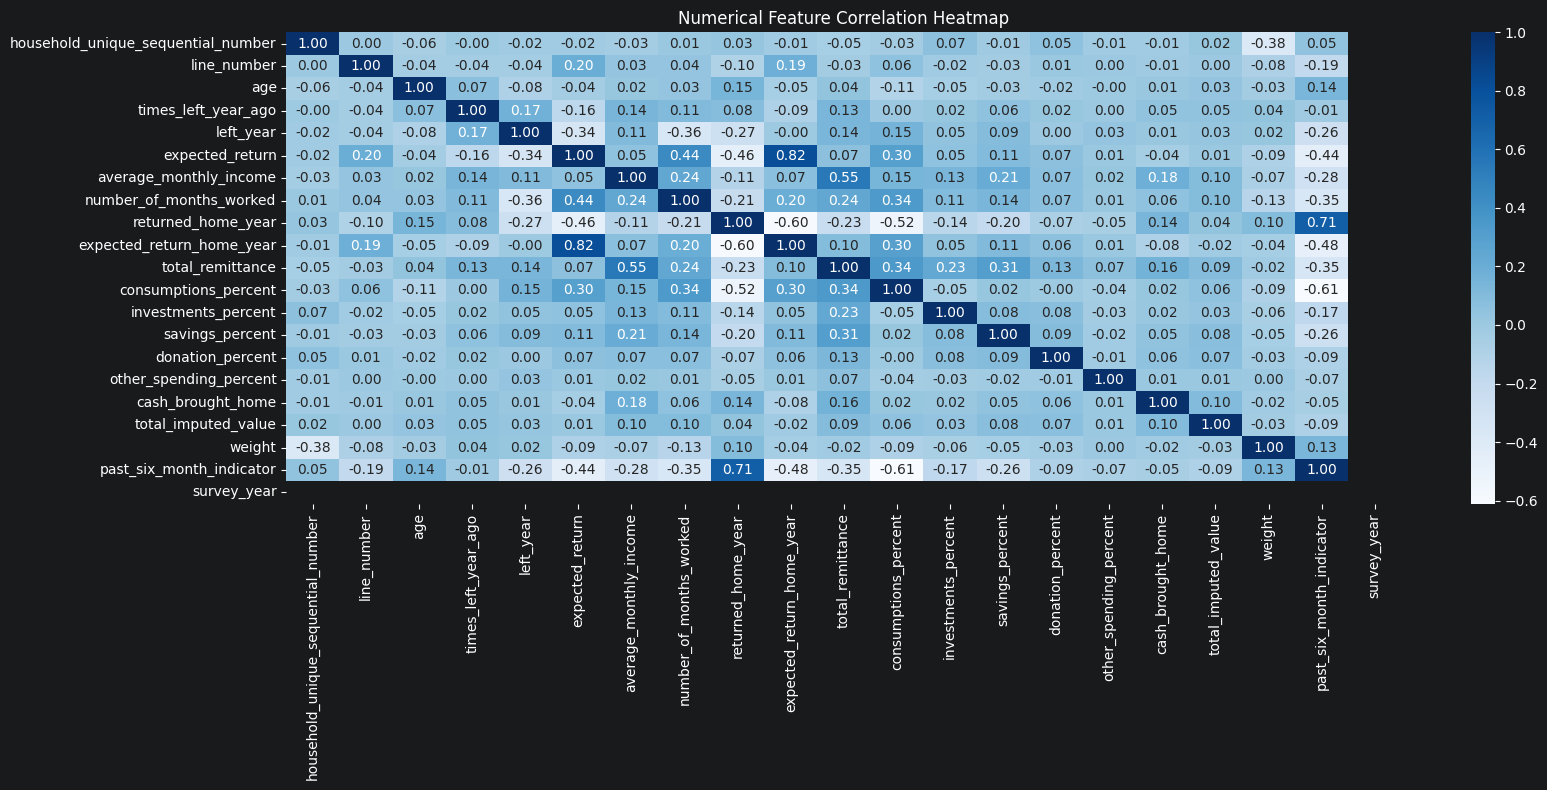

In [329]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(17, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', cbar=True)
plt.title('Numerical Feature Correlation Heatmap')
# Explicitly handles layout clipping for long labels
plt.tight_layout()
plt.show()

C:\Users\Joseph Rey\AppData\Local\Temp\ipykernel_26800\466236119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_allocations.values, y=[col.replace('_', ' ').title() for col in avg_allocations.index], palette='pastel')


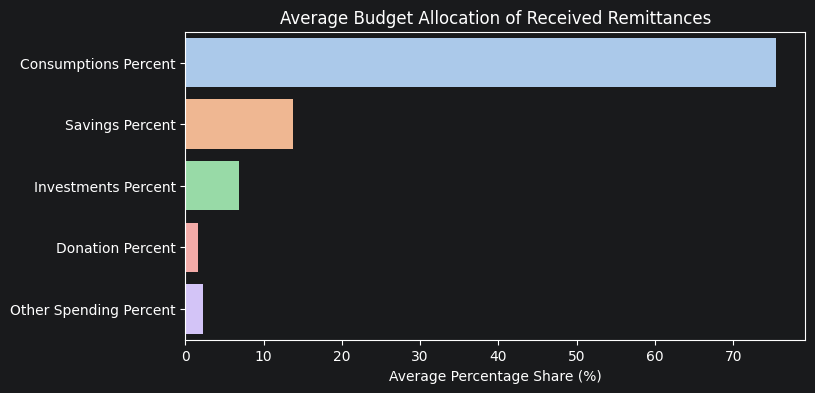

In [330]:
spending_headers = ['consumptions_percent', 'savings_percent', 'investments_percent', 'donation_percent', 'other_spending_percent']

# Calculate national average breakdown among households that receive remittances
avg_allocations = df[df['remittance_received'] == 'With Remittance'][spending_headers].mean()

# Visualize with a clean horizontal bar layout
plt.figure(figsize=(8, 4))
sns.barplot(x=avg_allocations.values, y=[col.replace('_', ' ').title() for col in avg_allocations.index], palette='pastel')
plt.title('Average Budget Allocation of Received Remittances')
plt.xlabel('Average Percentage Share (%)')
plt.show()

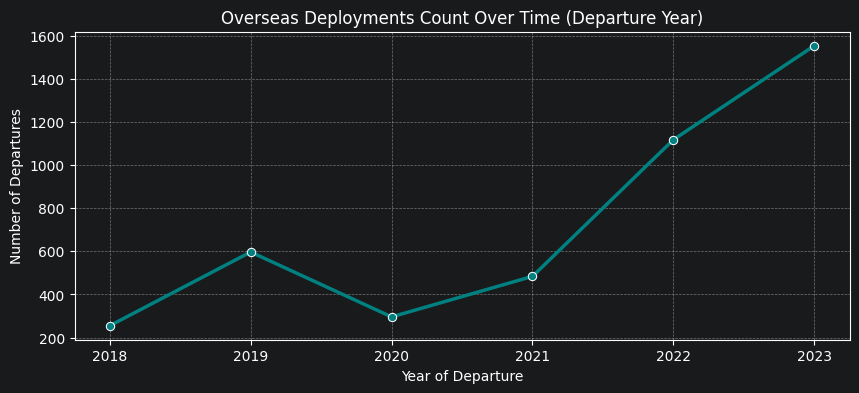

In [331]:
yearly_trends = df['left_year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x=yearly_trends.index.astype(str), y=yearly_trends.values, marker='o', linewidth=2.5, color='teal')
plt.title('Overseas Deployments Count Over Time (Departure Year)')
plt.xlabel('Year of Departure')
plt.ylabel('Number of Departures')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()